In [23]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import math

In [ ]:
class GeneticAlgorithmNQueens:
    def __init__(self, n, population_size=1000, mutation_rate=0.1, max_generations=10000):
        self.n = n
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.max_generations = max_generations
        self.population = self.initialize_population()
    
    def initialize_population(self):

        return [np.random.permutation(self.n) for _ in range(self.population_size)]
    
    def fitness(self, individual):

        conflicts = 0
        for i in range(self.n):
            for j in range(i + 1, self.n):
                if abs(individual[i] - individual[j]) == abs(i - j):
                    conflicts += 1
        
        max_conflicts = (self.n * (self.n - 1)) // 2
        return max_conflicts - conflicts
    
    def select_parents(self, fitnesses):

        total_fitness = sum(fitnesses)
        if total_fitness == 0:
            selection_probs = [1/len(fitnesses) for _ in fitnesses]
        else:
            selection_probs = [f/total_fitness for f in fitnesses]
            
        indices = np.random.choice(len(self.population), size=2, p=selection_probs)
        return self.population[indices[0]], self.population[indices[1]]
    
    def crossover(self, parent1, parent2):

        crossover_point = random.randint(1, self.n - 1)
        child = np.zeros(self.n, dtype=int)
        child[:crossover_point] = parent1[:crossover_point]
        remaining = [gene for gene in parent2 if gene not in child[:crossover_point]]
        child[crossover_point:] = remaining
        
        return child
    
    def mutate(self, individual):

        if random.random() < self.mutation_rate:
            i, j = random.sample(range(self.n), 2)
            individual[i], individual[j] = individual[j], individual[i]
        return individual
    
    def solve(self):

        best_fitness = 0
        best_individual = None
        generations_without_improvement = 0
        generation = 0
        
        while generation < self.max_generations:

            fitnesses = [self.fitness(ind) for ind in self.population]
            max_fitness_idx = np.argmax(fitnesses)
            current_best_fitness = fitnesses[max_fitness_idx]
            current_best_individual = self.population[max_fitness_idx]
            
            if current_best_fitness > best_fitness:
                best_fitness = current_best_fitness
                best_individual = current_best_individual.copy()
                generations_without_improvement = 0
                max_possible_fitness = (self.n * (self.n - 1)) // 2
                if best_fitness == max_possible_fitness:
                    break
            else:
                generations_without_improvement += 1
                
            if generations_without_improvement > 100:
                break
            
            new_population = []
            new_population.append(current_best_individual)
            
            while len(new_population) < self.population_size:

                parent1, parent2 = self.select_parents(fitnesses)
                child = self.crossover(parent1, parent2)
                child = self.mutate(child)
                new_population.append(child)
            
            self.population = new_population
            generation += 1
        
        return best_individual, best_fitness, generation
    
    def visualize_board(self, solution):
        board = np.zeros((self.n, self.n))
        
        for i in range(self.n):
            board[i, solution[i]] = 1
        
        plt.figure(figsize=(8, 8))
        plt.imshow(board, cmap='binary')
        plt.grid(True, color='black', linewidth=1.5)
        plt.xticks(np.arange(-.5, self.n, 1), [])
        plt.yticks(np.arange(-.5, self.n, 1), [])
        
        for i in range(self.n):
            plt.text(solution[i], i, '♛', fontsize=20, ha='center', va='center')
            
        plt.title(f'{self.n}-Queens Solution')
        plt.show()


In [18]:
def find_max_n(start_n=20, time_limit=600):
    current_n = start_n
    start_time = time.time()
    
    results = []
    
    while time.time() - start_time < time_limit:
        print(f"Attempting to solve {current_n}-Queens problem...")
        
        # Increase population size and max generations for larger boards
        population_size = min(400 + (current_n - 8) * 40, 4000)
        max_generations = min(2000 + (current_n - 8) * 200, 10000)
        
        solver = GeneticAlgorithmNQueens(
            n=current_n, 
            population_size=population_size,
            mutation_rate=0.1,
            max_generations=max_generations
        )
        
        try:
            solution, fitness, generations = solver.solve()
            max_fitness = (current_n * (current_n - 1)) // 2
            
            if fitness == max_fitness:
                print(f"Found solution for {current_n}-Queens in {generations} generations!")
                results.append((current_n, True, solution))
                current_n += 1
            else:
                print(f"Could not find perfect solution for {current_n}-Queens. Best fitness: {fitness}/{max_fitness}")
                results.append((current_n, False, solution))
                break
                
        except Exception as e:
            print(f"Error solving {current_n}-Queens: {e}")
            break
            
        # Check if we're reaching the time limit
        if time.time() - start_time > time_limit * 0.9:
            print("Approaching time limit, stopping search.")
            break
    
    # Report results
    solved_n_values = [n for n, solved, _ in results if solved]
    if solved_n_values:
        max_solved_n = max(solved_n_values)
        print(f"\nMaximum N successfully solved: {max_solved_n}")
        
        # Visualize the largest solved board
        solution = next(sol for n, solved, sol in results if n == max_solved_n and solved)
        solver = GeneticAlgorithmNQueens(n=max_solved_n)
        solver.visualize_board(solution)
    else:
        print(f"\nNo solutions found for N>={start_n}")
        max_solved_n = 0
        
    return max_solved_n, results

In [21]:
class SimulatedAnnealingNQueens:
    def __init__(self, n, max_iterations=100000, initial_temp=1.0, cooling_rate=0.99995):
        self.n = n
        self.max_iterations = max_iterations
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        
    def initialize_state(self):
        """Initialize a random state (one queen per row)"""
        return np.random.permutation(self.n)
    
    def calculate_conflicts(self, state):
        """Calculate the number of conflicts (attacking queens) in the current state"""
        conflicts = 0
        for i in range(self.n):
            for j in range(i + 1, self.n):
                # Queens are already in different rows by construction
                # Check for same column or diagonal conflicts
                if state[i] == state[j] or abs(state[i] - state[j]) == abs(i - j):
                    conflicts += 1
        return conflicts
    
    def generate_neighbor(self, state):
        """Generate a neighboring state by swapping two random rows"""
        neighbor = state.copy()
        i, j = random.sample(range(self.n), 2)
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
        return neighbor
    
    def acceptance_probability(self, old_cost, new_cost, temperature):
        """Calculate probability of accepting a worse solution"""
        if new_cost < old_cost:
            return 1.0  # Always accept better solutions
        return math.exp((old_cost - new_cost) / temperature)
    
    def solve(self):
        """Run the simulated annealing algorithm to find a solution"""
        # Start with a random state
        current_state = self.initialize_state()
        current_conflicts = self.calculate_conflicts(current_state)
        
        # Track the best solution found so far
        best_state = current_state.copy()
        best_conflicts = current_conflicts
        
        # Initialize temperature
        temperature = self.initial_temp
        
        # Statistics for visualization
        iteration_history = []
        conflict_history = []
        temperature_history = []
        
        # Main loop
        for iteration in range(self.max_iterations):
            # Record statistics
            if iteration % 100 == 0:
                iteration_history.append(iteration)
                conflict_history.append(current_conflicts)
                temperature_history.append(temperature)
            
            # Check if we've found a solution
            if current_conflicts == 0:
                break
                
            # Generate a neighbor
            neighbor_state = self.generate_neighbor(current_state)
            neighbor_conflicts = self.calculate_conflicts(neighbor_state)
            
            # Decide whether to accept the new state
            if random.random() < self.acceptance_probability(current_conflicts, 
                                                             neighbor_conflicts, 
                                                             temperature):
                current_state = neighbor_state
                current_conflicts = neighbor_conflicts
                
                # Update best solution if this is better
                if current_conflicts < best_conflicts:
                    best_state = current_state.copy()
                    best_conflicts = current_conflicts
            
            # Cool down the temperature
            temperature *= self.cooling_rate
            
            # If temperature is effectively zero, we're just doing hill climbing
            if temperature < 1e-8:
                break
        
        return {
            'solution': best_state,
            'conflicts': best_conflicts,
            'iterations': iteration,
            'stats': {
                'iterations': iteration_history,
                'conflicts': conflict_history,
                'temperature': temperature_history
            }
        }
    
    def visualize_board(self, solution):
        """Visualize the chessboard with queens"""
        board = np.zeros((self.n, self.n))
        
        # Place queens (1s) on the board
        for i in range(self.n):
            board[i, solution[i]] = 1
        
        plt.figure(figsize=(8, 8))
        plt.imshow(board, cmap='binary')
        
        # Add grid
        plt.grid(True, color='black', linewidth=1.5)
        plt.xticks(np.arange(-.5, self.n, 1), [])
        plt.yticks(np.arange(-.5, self.n, 1), [])
        
        # Place queen symbols
        for i in range(self.n):
            plt.text(solution[i], i, '♛', fontsize=20, ha='center', va='center')
            
        plt.title(f'{self.n}-Queens Solution')
        plt.show()
    
    def visualize_progress(self, stats):
        """Visualize the progress of the algorithm"""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # Plot conflicts over iterations
        ax1.plot(stats['iterations'], stats['conflicts'])
        ax1.set_xlabel('Iteration')
        ax1.set_ylabel('Number of Conflicts')
        ax1.set_title('Conflicts vs Iterations')
        ax1.grid(True)
        
        # Plot temperature over iterations
        ax2.plot(stats['iterations'], stats['temperature'])
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('Temperature')
        ax2.set_title('Temperature vs Iterations')
        ax2.set_yscale('log')
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()

def find_max_n_sa(start_n=8, time_limit=300):
    """Find the maximum N for which we can solve the N-Queens problem using Simulated Annealing"""
    current_n = start_n
    start_time = time.time()
    
    results = []
    
    while time.time() - start_time < time_limit:
        print(f"Attempting to solve {current_n}-Queens problem with Simulated Annealing...")
        
        # Adjust parameters based on problem size
        max_iterations = min(100000 + (current_n - 8) * 10000, 500000)
        initial_temp = 1.0 + (current_n / 10)  # Higher temp for larger problems
        cooling_rate = 1 - (0.0001 / (1 + (current_n - 8) * 0.001))  # Slower cooling for larger problems
        
        solver = SimulatedAnnealingNQueens(
            n=current_n,
            max_iterations=max_iterations,
            initial_temp=initial_temp,
            cooling_rate=cooling_rate
        )
        
        try:
            result = solver.solve()
            
            if result['conflicts'] == 0:
                print(f"Found solution for {current_n}-Queens in {result['iterations']} iterations!")
                results.append((current_n, True, result['solution']))
                current_n += 1
            else:
                print(f"Could not find perfect solution for {current_n}-Queens. Best conflicts: {result['conflicts']}")
                results.append((current_n, False, result['solution']))
                break
                
        except Exception as e:
            print(f"Error solving {current_n}-Queens: {e}")
            break
            
        # Check if we're reaching the time limit
        if time.time() - start_time > time_limit * 0.9:
            print("Approaching time limit, stopping search.")
            break
    
    # Report results
    solved_n_values = [n for n, solved, _ in results if solved]
    if solved_n_values:
        max_solved_n = max(solved_n_values)
        print(f"\nMaximum N successfully solved: {max_solved_n}")
        
        # Visualize the largest solved board
        solution = next(sol for n, solved, sol in results if n == max_solved_n and solved)
        solver = SimulatedAnnealingNQueens(n=max_solved_n)
        solver.visualize_board(solution)
    else:
        print(f"\nNo solutions found for N>={start_n}")
        max_solved_n = 0
        
    return max_solved_n, results

# Test a specific N
def test_n_queens_sa(n=20):
    print(f"Solving {n}-Queens problem with Simulated Annealing...")
    
    # Adjust parameters based on problem size
    max_iterations = 200000
    initial_temp = 2.0
    cooling_rate = 0.99995
    
    start_time = time.time()
    
    solver = SimulatedAnnealingNQueens(
        n=n,
        max_iterations=max_iterations,
        initial_temp=initial_temp,
        cooling_rate=cooling_rate
    )
    
    result = solver.solve()
    
    end_time = time.time()
    elapsed = end_time - start_time
    
    print(f"Time taken: {elapsed:.2f} seconds")
    print(f"Iterations: {result['iterations']}")
    print(f"Conflicts: {result['conflicts']}")
    
    if result['conflicts'] == 0:
        print("Solution found!")
        solver.visualize_board(result['solution'])
        solver.visualize_progress(result['stats'])
    else:
        print("No perfect solution found.")
        
    return result

Solving 50-Queens problem with Simulated Annealing...
Time taken: 15.21 seconds
Iterations: 37445
Conflicts: 0
Solution found!


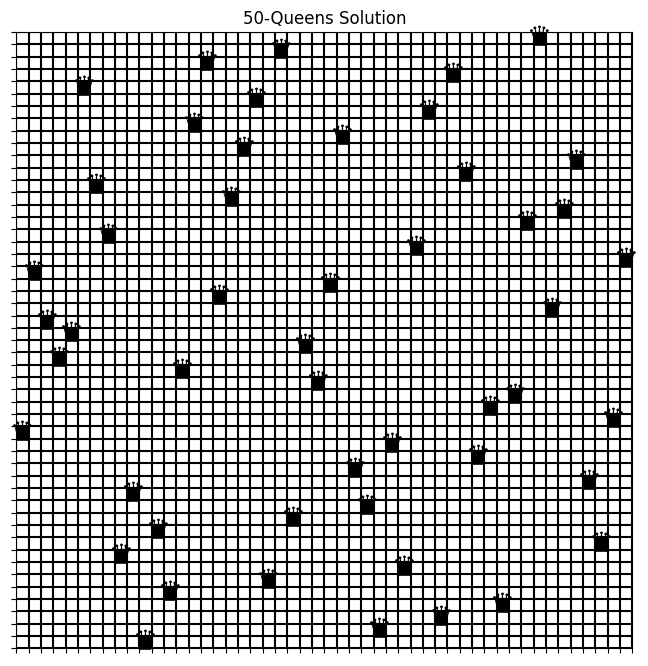

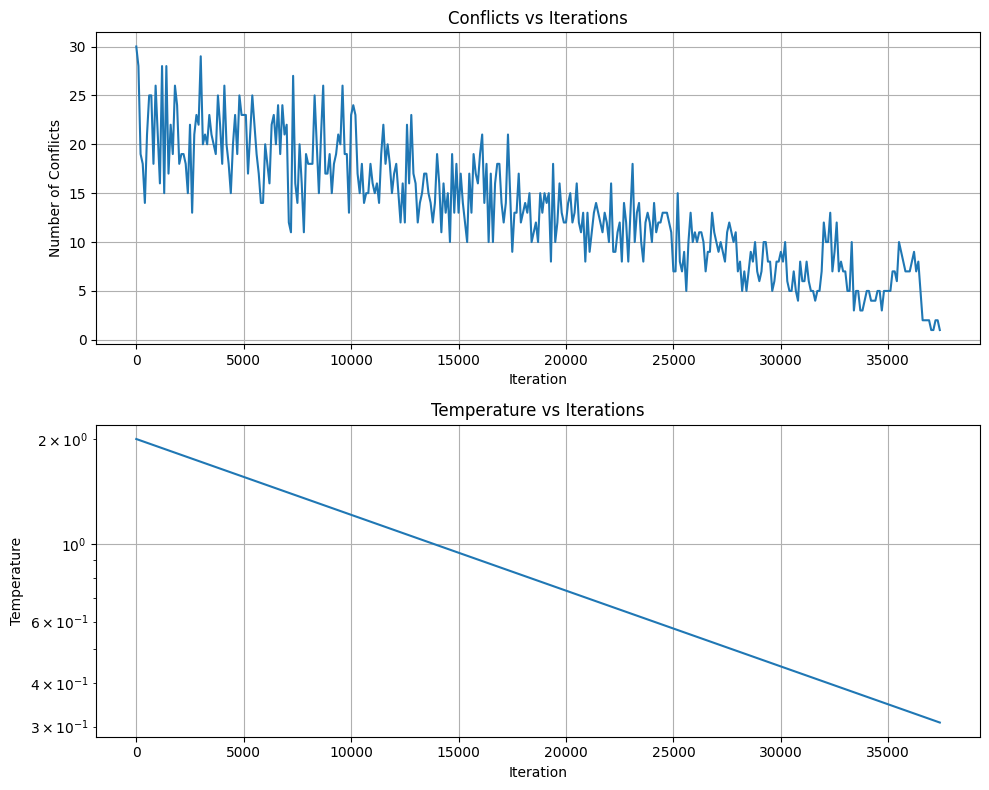


Experiment completed!


In [25]:
np.random.seed(999)
random.seed(999)
    
# GA Algorithm
# max_n, all_results = find_max_n(start_n=20, time_limit=180)

test_n_queens_sa(n=50)
    
print("\nExperiment completed!")